# Notebook 04 — GDELT Processor (Live Feed)

## What is GDELT?

The **Global Database of Events, Language, and Tone (GDELT)** monitors  
print/broadcast/web news in 100+ languages **every 15 minutes**, 24/7.

| Property | Value |
|---|---|
| Update frequency | **Every 15 minutes** |
| Coverage | 100+ languages, 200+ countries |
| GKG fields | Themes, Locations, Persons, Orgs, Tone, Quotations |
| API | Free, public — no authentication required |

### Live vs. Static

| Mode | Data freshness | When to use |
|---|---|---|
| `fetch_latest_gkg()` | **< 15 minutes old** (always current) | Production / demo |
| `fetch_last_n_gkg(n=16)` | Last 4 hours | Richer theme coverage |
| Local `.gkg.csv` file | Snapshot at file creation time | Offline / reproducibility |

> This notebook defaults to **live mode** — it fetches the newest snapshot  
> from `http://data.gdeltproject.org/gdeltv2/lastupdate.txt` each time it runs.


In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: /Users/kk/ai_dl_project/dynamic-trend-event-detector


## GDELT Processing Pipeline Diagram

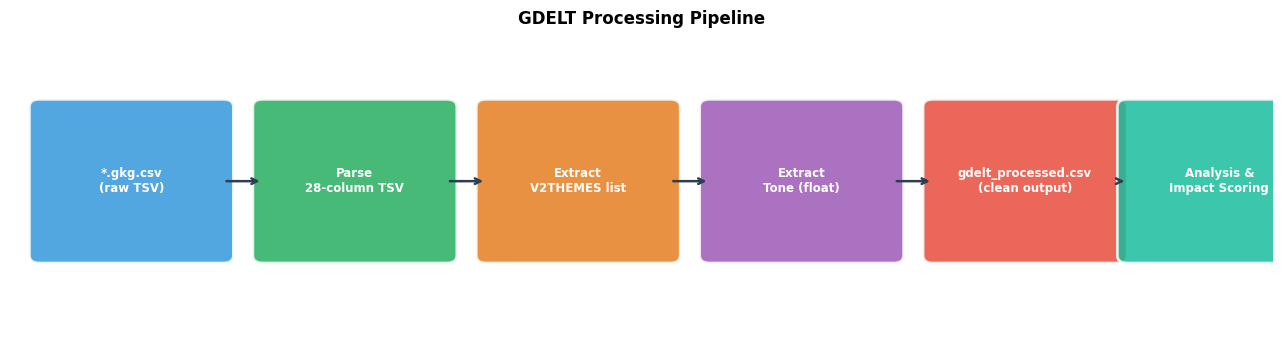

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis('off')

stages = [
    (0.3, '*.gkg.csv\n(raw TSV)', '#3498DB'),
    (2.6, 'Parse\n28-column TSV', '#27AE60'),
    (4.9, 'Extract\nV2THEMES list', '#E67E22'),
    (7.2, 'Extract\nTone (float)', '#9B59B6'),
    (9.5, 'gdelt_processed.csv\n(clean output)', '#E74C3C'),
    (11.5, 'Analysis &\nImpact Scoring', '#1ABC9C'),
]
for x, label, color in stages:
    box = FancyBboxPatch((x, 1.0), 1.9, 2.0,
                         boxstyle='round,pad=0.1',
                         facecolor=color, edgecolor='white',
                         linewidth=2, alpha=0.85)
    ax.add_patch(box)
    ax.text(x + 0.95, 2.0, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')

for i in range(len(stages) - 1):
    ax.annotate('', xy=(stages[i+1][0], 2.0), xytext=(stages[i][0] + 1.9, 2.0),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.8))

ax.set_title('GDELT Processing Pipeline', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/gdelt_pipeline_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

## Implementation

In [3]:
import sys, os, pandas as pd

# ── Live fetch ───────────────────────────────────────────────────────────────
# gdelt_fetcher always downloads the most recent 15-min GKG snapshot from
# the GDELT 2.0 public API, replacing whatever static file is on disk.
try:
    from src.gdelt_fetcher import fetch_latest_gkg
    processed_df = fetch_latest_gkg(save_to='data/gdelt_processed.csv')

except Exception as e:
    # ── Offline fallback: local .gkg.csv ─────────────────────────────────────
    print(f"Live fetch failed ({e}). Using local GKG file …")
    GKG_COLUMNS = [
        'GKGRECORDID','DATE','SOURCECOLLECTIONID','SOURCECOMMONNAME','DOCUMENTIDENTIFIER',
        'COUNTS','V2COUNTS','THEMES','V2THEMES','LOCATIONS','V2LOCATIONS','PERSONS',
        'V2PERSONS','ORGANIZATIONS','V2ORGANIZATIONS','TONE','V2TONE','ENHANCEDDATES',
        'GCAM','SHARINGIMAGE','RELATEDIMAGES','SOCIALIMAGEEMBEDS','SOCIALVIDEOEMBEDS',
        'QUOTATIONS','ALLNAMES','AMOUNTS','TRANSLATIONINFO','EXTRASXML'
    ]
    gkg_files = sorted([f for f in os.listdir('data') if f.endswith('.gkg.csv')], reverse=True)
    if not gkg_files:
        raise FileNotFoundError("No local .gkg.csv file found — check data/ folder.")
    raw = pd.read_csv(f'data/{gkg_files[0]}', sep='\t', names=GKG_COLUMNS,
                      encoding='utf-8', on_bad_lines='skip', low_memory=False)
    def _themes(v): return [] if pd.isna(v) else [i.split(',')[0] for i in v.split(';') if i]
    def _tone(t):
        try: return float(str(t).split(',')[0])
        except: return 0.0
    raw['theme_list'] = raw['V2THEMES'].apply(_themes)
    raw['tone_value'] = raw['TONE'].apply(_tone)
    processed_df = raw[['GKGRECORDID','DATE','SOURCECOMMONNAME',
                         'DOCUMENTIDENTIFIER','theme_list','tone_value']]
    processed_df.to_csv('data/gdelt_processed.csv', index=False)
    print(f"Fallback: saved {len(processed_df):,} records from {gkg_files[0]}")

print(f"\n✅ GDELT records loaded: {len(processed_df):,}")
print(f"Date range in snapshot: {processed_df['DATE'].min()} → {processed_df['DATE'].max()}")
display(processed_df.head(3))


Fetching latest GDELT GKG snapshot …


  Latest snapshot: 20260412101500
  [download] 20260412101500.gkg.csv.zip … 

2327 KB
  Parsed 558 records from snapshot 20260412101500
  Saved → data/gdelt_processed.csv

✅ GDELT records loaded: 558
Date range in snapshot: 20260412101500 → 20260412101500


,GKGRECORDID,DATE,SOURCECOMMONNAME,DOCUMENTIDENTIFIER,theme_list,tone_value
0,20260412101500-0,20260412101500,pakistantoday.com.pk,https://www.pakistantoday.com.pk/2026/04/12/gb...,"[TAX_FNCACT_PRIME_MINISTER, RECRUITMENT, RECRU...",0.225734
1,20260412101500-1,20260412101500,livemint.com,https://www.livemint.com/money/personal-financ...,"[WB_1675_GRADUATION, WB_855_LABOR_MARKETS, WB_...",-0.492611
2,20260412101500-2,20260412101500,pakistantoday.com.pk,https://www.pakistantoday.com.pk/2026/04/12/po...,"[TAX_FNCACT_AUTHORITIES, EPU_POLICY_AUTHORITIE...",-5.232558


## How the Live Feed Works

```
GDELT API (every 15 min)
    │
    ▼
lastupdate.txt  ──►  newest GKG URL  ──►  download .gkg.csv.zip
    │                                            │
    │                                     unzip in-memory
    │                                            │
    │                              parse TSV (28 columns)
    │                                            │
    └──── offline? ──► local .gkg.csv ──►  extract themes + tone
                                                 │
                                          gdelt_processed.csv
                                                 │
                              ┌──────────────────┼────────────────┐
                              ▼                  ▼                ▼
                       gdelt_analysis     event_impact_scoring   GDELT verify
                       (top themes)       (S_I = uniqueness×|tone|)  (rupture check)
```

### To fetch more historical windows:
```python
from src.gdelt_fetcher import fetch_last_n_gkg
df = fetch_last_n_gkg(n=16)   # last 4 hours
df = fetch_last_n_gkg(n=96)   # last 24 hours
```

### Cache behaviour
Downloaded ZIP files are cached in `data/gdelt_cache/`. Subsequent runs skip  
the download and read from cache. To force a fresh download, delete the cache folder.
